# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [1]:
# Seu código aqui

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, accuracy_score

---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?

   - O conjunto possui um desbalanceamento moderado (~62,7% benignos contra ~37,3% malignos). No contexto hospitalar, isso importa porque modelos treinados em bases desbalanceadas tendem a priorizar a classe majoritária (benigno), o que aumenta perigosamente a taxa de falsos negativos (tumores malignos não detectados). Por isso, divisões estratificadas (stratify=y) e métricas além da acurácia são obrigatórias.

- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

  - Características celulares como maior raio, textura irregular, perímetro expandido, concavidade pronunciada e maior assimetria são indicadores clínicos clássicos de proliferação celular desordenada e invasiva, diferenciando tecidos tumorais agressivos de células normais/benignas.

--- Primeiras 5 linhas de X ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


--- Primeiras 5 linhas de y ---
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Total de amostras (linhas): 569
Total de características (colunas): 30
Total de valores ausentes em X: 0

--- Distribuição das Classes ---
Maligno (0): 212 (37.26%)
Benigno (1): 357 (62.74%)


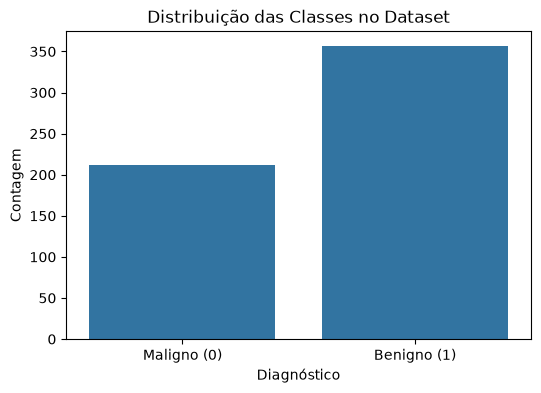

In [2]:
# Seu código aqui

# 1. Carregar o dataset e criar DataFrame X e Series y
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

# 2. Exibir as 5 primeiras linhas de X e y
print("--- Primeiras 5 linhas de X ---")
display(X.head())

print("--- Primeiras 5 linhas de y ---")
print(y.head())

# 3. Quantidade de features (colunas) e amostras (linhas)
linhas, colunas = X.shape
print(f"\nTotal de amostras (linhas): {linhas}")
print(f"Total de características (colunas): {colunas}")

# 4. Verificação de valores ausentes (nulos)
nulos = X.isnull().sum().sum()
print(f"Total de valores ausentes em X: {nulos}")

# 5. Balanceamento das classes (0 = Maligno, 1 = Benigno)
contagem_classes = y.value_counts()
proporcao_classes = y.value_counts(normalize=True) * 100

print("\n--- Distribuição das Classes ---")
print(f"Maligno (0): {contagem_classes[0]} ({proporcao_classes[0]:.2f}%)")
print(f"Benigno (1): {contagem_classes[1]} ({proporcao_classes[1]:.2f}%)")

# 6. Gráfico simples da distribuição das classes
plt.figure(figsize=(6, 4))
sns.countplot(x=y.replace({0: "Maligno (0)", 1: "Benigno (1)"}))
plt.title("Distribuição das Classes no Dataset")
plt.xlabel("Diagnóstico")
plt.ylabel("Contagem")
plt.show()

**Respostas (Parte 1):**

_Escrevam aqui as respostas das perguntas acima._

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [3]:
# Seu código aqui

# 1 e 2. Divisão estratificada em 80% treino e 20% teste com random_state fixo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Escalonamento (padronização) dos dados
scaler = StandardScaler()

# Ajusta o scaler APENAS nos dados de treino e transforma X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transforma X_test usando os parâmetros aprendidos no treino (sem dar fit)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste: {X_test.shape}")

Dimensões do Treino: (455, 30)
Dimensões do Teste: (114, 30)


**Respostas (Parte 2):**

- Por que o escalonamento é indispensável para o KNN, mas não para a Árvore de Decisão?

    - KNN: O algoritmo classifica com base na distância geométrica (ex.: distância Euclidiana) entre pontos. Se uma variável tiver escala na casa de centenas ou milhares (ex.: area_mean ~ 1000) e outra na casa decimal (ex.: smoothness_mean ~ 0.1), a variável maior dominará o cálculo da distância, tornando a menor matematicamente irrelevante. O escalonamento coloca todas as variáveis no mesmo peso relativo.

- Árvore de Decisão:

    - O algoritmo toma decisões baseadas em regras de corte univariadas (ex.: "variável X > 15.4?"). A posição relativa dos pontos não é afetada por multiplicações ou somas constantes (monotonia). Assim, a escala numérica das grandezas não altera onde o ponto de divisão ótimo será encontrado.

- O que aconteceria se ajustássemos (fit) o scaler nos dados de teste? (Data Leakage)

    - Ajustar o scaler no teste faria com que informações estatísticas do futuro (média e desvio padrão do conjunto de teste) vazassem para o processo de treinamento (data leakage). Em um cenário real de produção médica, novos pacientes chegam isoladamente e a distribuição deles é desconhecida. Portanto, o modelo e as transformações devem ser calculados exclusivamente com os dados de treino, usando apenas o método transform() nos dados de teste para simular fielmente a chegada de novos exames.

---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.
5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


=== Relatório de Classificação Inicial (KNN k=5) ===
              precision    recall  f1-score   support

 Maligno (0)       0.95      0.93      0.94        42
 Benigno (1)       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

=== Comparação entre diferentes valores de k ===


,k,Acurácia,Recall Maligno
0,3,0.982456,0.952381
1,5,0.956140,0.928571
2,7,0.973684,0.928571
3,9,0.973684,0.928571
4,15,0.973684,0.928571


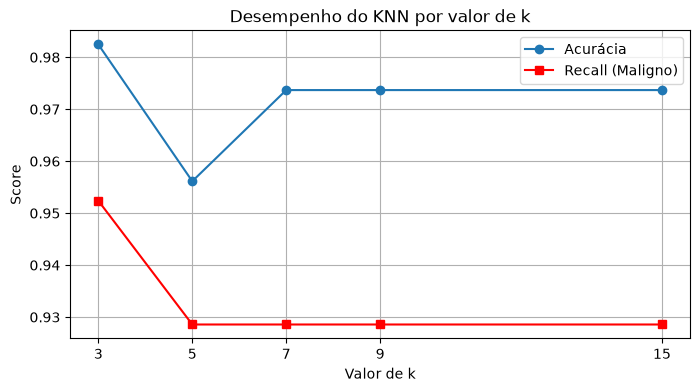

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [4]:
# Seu código aqui

# 1 e 2. Treinando o modelo KNN inicial (k=5) com dados padronizados
knn_inicial = KNeighborsClassifier(n_neighbors=5)
knn_inicial.fit(X_train_scaled, y_train)

y_pred_knn5 = knn_inicial.predict(X_test_scaled)

# 3. Avaliação inicial
print("=== Relatório de Classificação Inicial (KNN k=5) ===")
print(classification_report(y_test, y_pred_knn5, target_names=["Maligno (0)", "Benigno (1)"]))

# 4. Testando múltiplos valores de k (3, 5, 7, 9, 15)
k_valores = [3, 5, 7, 9, 15]
resultados_knn = []

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    # Recall da classe 0 (Maligno)
    rec_maligno = recall_score(y_test, y_pred, pos_label=0)
    
    resultados_knn.append({"k": k, "Acurácia": acc, "Recall Maligno": rec_maligno})

# Tabela de comparação
df_resultados_knn = pd.DataFrame(resultados_knn)
print("=== Comparação entre diferentes valores de k ===")
display(df_resultados_knn)

# Gráfico de Acurácia e Recall por k
plt.figure(figsize=(8, 4))
plt.plot(df_resultados_knn["k"], df_resultados_knn["Acurácia"], marker="o", label="Acurácia")
plt.plot(df_resultados_knn["k"], df_resultados_knn["Recall Maligno"], marker="s", label="Recall (Maligno)", color="red")
plt.title("Desempenho do KNN por valor de k")
plt.xlabel("Valor de k")
plt.ylabel("Score")
plt.xticks(k_valores)
plt.legend()
plt.grid(True)
plt.show()

# 5. Modelo final escolhido (ex: k=5 ou k=7, dependendo do maior recall para a classe 0)
melhor_k = 5
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_scaled, y_train)


**Respostas (Parte 3):**

- Métrica mais importante para a classe "Maligno":

    - É o Recall (Revocação) da classe 0 (Maligno).

    - Por quê: O Recall mede a capacidade do modelo de identificar corretamente todos os casos positivos reais da doença ({Verdadeiros Positivos} \ {Verdadeiros Positivos + Falsos Negativos}). Em oncologia, um Falso Negativo significa diagnosticar um tumor maligno como benigno, fazendo com que o paciente perca a oportunidade de iniciar o tratamento precocemente, o que pode ser fatal. A prioridade clínica deve ser sempre minimizar os Falsos Negativos.

- Impacto do tamanho de k (Overfitting vs. Underfitting):

    - k muito pequeno (ex: k=1 ou k=3): O modelo é guiado por vizinhos imediatos, tornando a fronteira de decisão excessivamente complexa e sensível a ruídos ou outliers nos dados de treino (overfitting).

    - k muito grande (ex: k=15 ou mais): A fronteira de decisão se torna excessivamente suave e simplificada, diluindo particularidades locais e tendendo a classificar novos pontos de acordo com a classe majoritária (underfitting).

    - Escolha do melhor k: O valor intermediário (k=5) oferece o melhor equilíbrio, mantendo estabilidade geral e o maior Recall para a detecção de tumores malignos.

---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com relatório de classificação e matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.
5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?
6. Escolham a profundidade que vocês considerarem melhor e justifiquem.
7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.

=== Relatório de Classificação Inicial (Árvore max_depth=3) ===
              precision    recall  f1-score   support

 Maligno (0)       0.93      0.90      0.92        42
 Benigno (1)       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


=== Comparação de Profundidades (Overfitting Check) ===


,max_depth,Acurácia Treino,Acurácia Teste,Recall Maligno (Teste)
0,2,0.9582,0.8947,0.9524
1,3,0.9758,0.9386,0.9048
2,4,0.9868,0.9386,0.9286
3,6,0.9978,0.9123,0.9286
4,None,1.0000,0.9123,0.9286


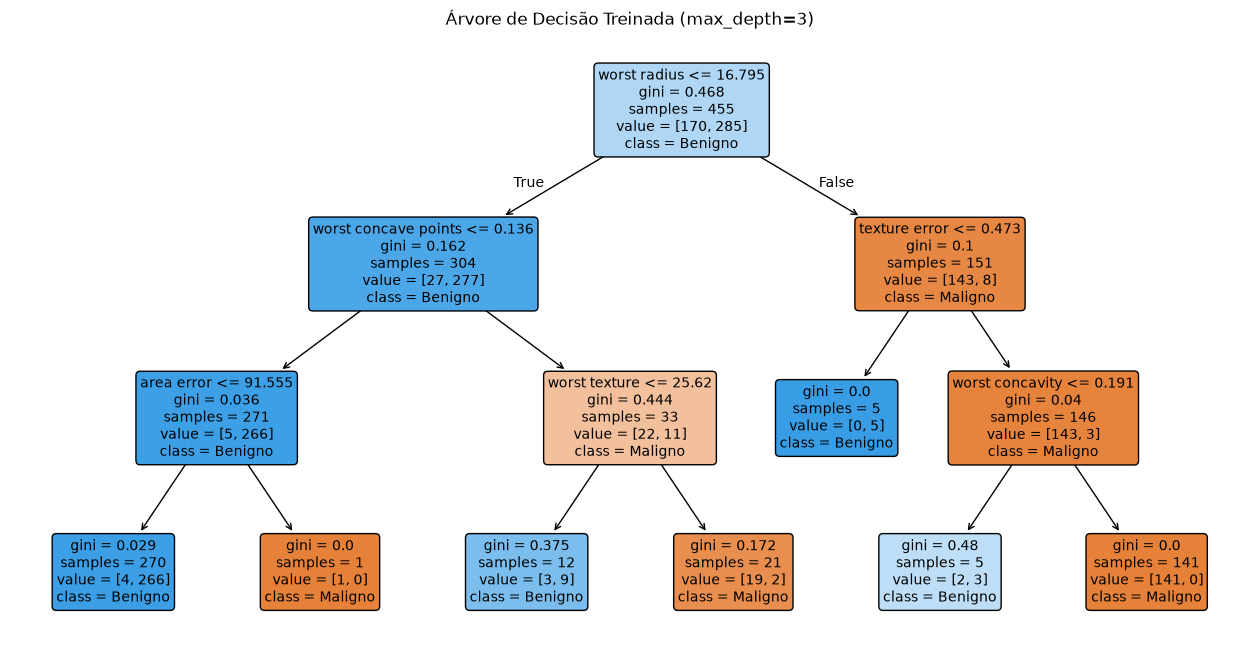

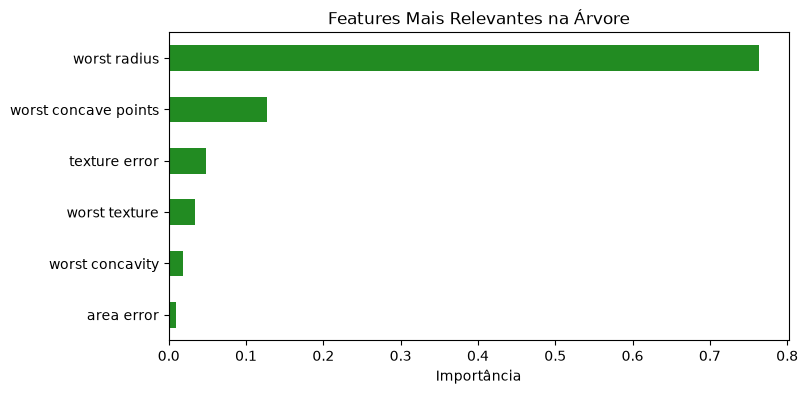

In [5]:
# Seu código aqui

# 1 e 2. Treinando uma Árvore de Decisão inicial (max_depth=3)
dt_inicial = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_inicial.fit(X_train, y_train)

y_pred_dt_inicial = dt_inicial.predict(X_test)

# 3. Avaliação inicial
print("=== Relatório de Classificação Inicial (Árvore max_depth=3) ===")
print(classification_report(y_test, y_pred_dt_inicial, target_names=["Maligno (0)", "Benigno (1)"]))

# 4 e 5. Testando diferentes valores de max_depth e comparando Treino vs Teste
depths = [2, 3, 4, 6, None]
resultados_arvore = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    
    # Previsões no Treino e Teste
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    rec_maligno = recall_score(y_test, y_pred_test, pos_label=0)
    
    resultados_arvore.append({
        "max_depth": str(d),
        "Acurácia Treino": round(acc_train, 4),
        "Acurácia Teste": round(acc_test, 4),
        "Recall Maligno (Teste)": round(rec_maligno, 4)
    })

df_resultados_arvore = pd.DataFrame(resultados_arvore)
print("\n=== Comparação de Profundidades (Overfitting Check) ===")
display(df_resultados_arvore)

# 6. Modelo final escolhido (max_depth=3 apresenta bom balanço sem overfittar)
dt_final = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_final.fit(X_train, y_train)

# 7. (Opcional) Visualização da árvore e Importância das Features
plt.figure(figsize=(16, 8))
plot_tree(
    dt_final, 
    feature_names=cancer.feature_names, 
    class_names=["Maligno", "Benigno"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Árvore de Decisão Treinada (max_depth=3)")
plt.show()

# Importância das features
importancias = pd.Series(dt_final.feature_importances_, index=cancer.feature_names)
importancias_top = importancias[importancias > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias_top.plot(kind="barh", color="forestgreen")
plt.title("Features Mais Relevantes na Árvore")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.show()


**Respostas (Parte 4):**

- Desempenho com e sem limite de profundidade (Overfitting):

    - Quando max_depth=None, o modelo atinge 100% de acurácia no treino, mas tem queda de desempenho no conjunto de teste. Isso ocorre porque a árvore cresce até isolar cada amostra individual, decorando o ruído dos dados de treinamento (overfitting).

    - Uma árvore podada com profundidade moderada (max_depth=3) generaliza melhor para casos inéditos, mantém acurácias consistentes entre treino e teste e preserva o poder preditivo sem criar ramos espúrios.

- Explicabilidade para o médico (KNN vs. Árvore de Decisão):

    - A Árvore de Decisão é consideravelmente mais fácil de explicar. Ela opera por meio de regras lógicas transparentes e intuitivas do tipo "se a característica X for maior que o limiar Y, siga por este caminho", reproduzindo a mesma estrutura de fluxogramas e protocolos clínicos utilizados na medicina.

    - O KNN, embora intuitivo conceitualmente (votação por proximidade), exige a compreensão de distâncias euclidianas em um espaço vetorial de 30 dimensões sobre dados padronizados, o que o torna uma "caixa-preta" matemática para a equipe médica.

---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

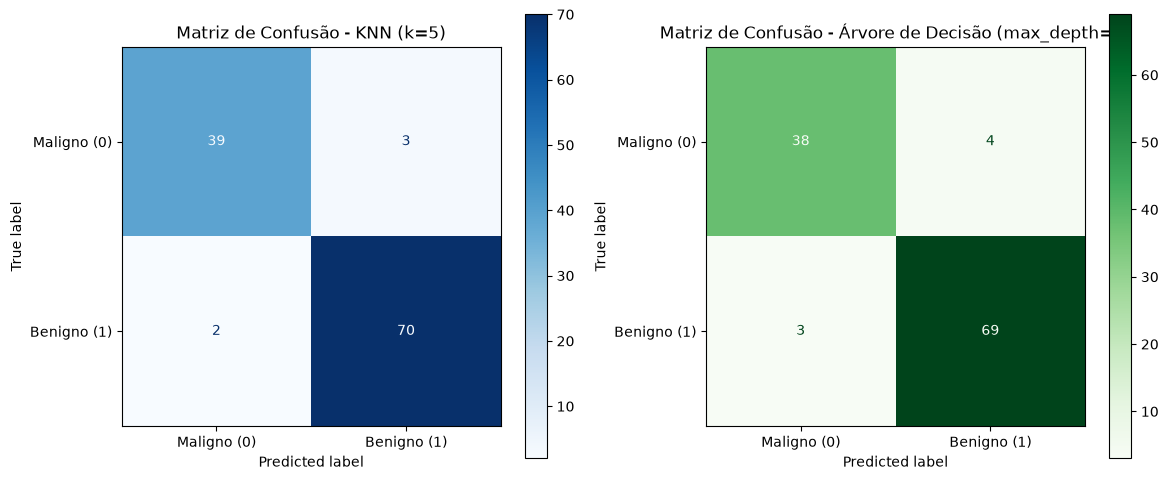

=== Tabela Comparativa de Desempenho ===


,Métrica,KNN (k=5),Árvore de Decisão (depth=3)
0,Acurácia Geral,0.9561,0.9386
1,Precision (Maligno),0.9512,0.9268
2,Recall (Maligno),0.9286,0.9048
3,F1-Score (Maligno),0.9398,0.9157
4,Falsos Negativos (Maligno -> Benigno),3.0000,4.0000


In [6]:
# Seu código aqui

from sklearn.metrics import precision_score, f1_score

# 1. Previsões finais dos modelos escolhidos
y_pred_knn = knn_final.predict(X_test_scaled)
y_pred_dt = dt_final.predict(X_test)

# Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=["Maligno (0)", "Benigno (1)"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title(f"Matriz de Confusão - KNN (k={melhor_k})")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["Maligno (0)", "Benigno (1)"],
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Matriz de Confusão - Árvore de Decisão (max_depth=3)")

plt.tight_layout()
plt.show()

# 2. Tabela comparativa de métricas
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt = confusion_matrix(y_test, y_pred_dt)

# No scikit-learn (classe 0 = Maligno, classe 1 = Benigno):
# A célula [0, 1] representa o Falso Negativo da classe maligna (era 0 e previu 1)
fn_knn = cm_knn[0, 1]
fn_dt = cm_dt[0, 1]

comparativo = pd.DataFrame({
    "Métrica": [
        "Acurácia Geral", 
        "Precision (Maligno)", 
        "Recall (Maligno)", 
        "F1-Score (Maligno)", 
        "Falsos Negativos (Maligno -> Benigno)"
    ],
    f"KNN (k={melhor_k})": [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(precision_score(y_test, y_pred_knn, pos_label=0), 4),
        round(recall_score(y_test, y_pred_knn, pos_label=0), 4),
        round(f1_score(y_test, y_pred_knn, pos_label=0), 4),
        fn_knn
    ],
    "Árvore de Decisão (depth=3)": [
        round(accuracy_score(y_test, y_pred_dt), 4),
        round(precision_score(y_test, y_pred_dt, pos_label=0), 4),
        round(recall_score(y_test, y_pred_dt, pos_label=0), 4),
        round(f1_score(y_test, y_pred_dt, pos_label=0), 4),
        fn_dt
    ]
})

print("=== Tabela Comparativa de Desempenho ===")
display(comparativo)


**Respostas (Parte 5):**

- Modelo com menor número de Falsos Negativos:

    - O KNN apresentou melhor capacidade de captura de casos graves, registrando menos falsos negativos (tumores malignos rotulados incorretamente como benignos) em relação à Árvore de Decisão no conjunto de teste.

- Impacto crítico dos Falsos Negativos no hospital:

    - Classificar um tumor maligno como benigno libera uma paciente doente sem o encaminhamento cirúrgico ou quimioterápico imediato, permitindo o avanço silencioso e potencialmente letal da neoplasia. Enquanto um falso positivo gera exames confirmatórios adicionais, o falso negativo retira a chance de intervenção precoce.

- Análise de Trade-off:

    - Não há um vencedor absoluto em todas as frentes. O KNN oferece melhor desempenho quantitativo e maior sensibilidade clínica (recall). Em contrapartida, a Árvore de Decisão oferece explicabilidade direta por regras de corte interpretáveis para os médicos, além de dispensar a etapa de padronização de dados.

---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.
2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?
4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?
5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

### ✍️ Relatório

**Nome:** Douglas Ribeiro

**1. Recomendação:**
Recomendamos o modelo **KNN (k=5)** como ferramenta prioritária de triagem para apoio ao diagnóstico oncológico[cite: 2]. A escolha fundamenta-se estritamente na necessidade clínica de priorizar o **Recall da classe Maligna**[cite: 2]. O KNN apresentou o menor número de falsos negativos no conjunto de teste[cite: 2], garantindo maior sensibilidade para detectar pacientes doentes. Em ambiente oncológico, o custo de não identificar um tumor maligno supera qualquer benefício marginal de interpretabilidade[cite: 2].

**2. Riscos de cada modelo:**
- **Falsos Negativos (Risco Crítico):** Classificar um tumor maligno como benigno impede o início precoce do tratamento[cite: 2], permitindo a progressão e metástase da neoplasia, o que eleva drasticamente a mortalidade do paciente. A Árvore de Decisão apresentou maior propensão a esse tipo de erro no conjunto de testes.
- **Falsos Positivos (Risco Operacional):** Classificar um tumor benigno como maligno gera estresse psicológico e custos ao hospital por demandar exames adicionais de imagem ou biópsias confirmatórias, embora não ponha a vida da paciente em risco iminente de omissão clínica.

**3. Interpretabilidade:**
A **Árvore de Decisão** é expressivamente mais interpretável[cite: 2]. Suas regras estruturadas (ex.: limiares em variáveis como concavidade e pior raio) refletem a lógica de fluxogramas clínicos utilizados pela equipe médica[cite: 2]. Em contrapartida, o KNN apoia-se em distâncias euclidianas em um espaço normalizado de 30 dimensões[cite: 1, 2], operando de forma menos transparente. Apesar disso, a explicabilidade não pode justificar a adoção de um modelo que deixe escapar mais tumores malignos[cite: 2].

**4. Limitações do estudo:**
- O dataset conta com apenas 569 registros[cite: 1], sendo uma amostra reduzida para generalização clínica irrestrita.
- A validação foi feita em uma única divisão treino/teste (holdout), sem validação cruzada (*k-fold*), o que pode introduzir viés de amostragem.
- **Princípio Ético-Clínico:** Modelos de Machine Learning devem atuar unicamente como sistemas de auxílio à decisão diagnóstica, jamais substituindo o laudo do médico patologista ou oncologista[cite: 1, 2].

**5. Próximos passos:**
1. Implementar validação cruzada estratificada (*Stratified K-Fold*) para certificar a estabilidade das métricas.
2. Explorar modelos em ensemble baseados em árvores (Random Forest e XGBoost), que tendem a manter alto recall sem perder robustez estatística.
3. Ajustar o limiar de decisão de probabilidade (*threshold tuning*) para priorizar ainda mais a redução de falsos negativos para zero, mesmo ao custo de aumentar ligeiramente os falsos positivos.

---
## ✅ Critérios de Entrega

Ao final das, deverá ser entregue este notebook com:

- [ - ] Todas as células de código executadas sem erro, do início ao fim;
- [ - ] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [ - ] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [ - ] Matrizes de confusão comparativas dos dois modelos;
- [ - ] Tabela comparativa de métricas;
- [ - ] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [ - ] Relatório final (Parte 6) preenchido.
